In [ ]:
!git clone https://github.com/NVIDIA-AI-IOT/torch2trt

In [ ]:
%cd torch2trt

In [ ]:
pwd

In [ ]:
!pip install tensorrt --extra-index-url https://pypi.nvidia.com

In [ ]:
!python setup.py install

In [ ]:
!git clone https://github.com/NVIDIA-AI-IOT/nanosam

In [ ]:
%cd nanosam


In [ ]:
!python setup.py develop --user

In [ ]:
#download https://drive.google.com/file/d/1jYNvnseTL49SNRx9PDcbkZ9DwsY8up7n/view


!trtexec   --onnx=data/mobile_sam_mask_decoder.onnx   --saveEngine=data/mobile_sam_mask_decoder.engine   --minShapes=point_coords:1x1x2,point_labels:1x1   --optShapes=point_coords:1x1x2,point_labels:1x1     --maxShapes=point_coords:1x10x2,point_labels:1x10

In [93]:
#test onnx
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor
from segment_anything.utils.onnx import SamOnnxModel

import onnxruntime
from onnxruntime.quantization import QuantType
from onnxruntime.quantization.quantize import quantize_dynamic

In [94]:
checkpoint = "D:\\nhan\\viko\src\sam_vit_h_4b8939.pth"
model_type = "vit_h"

In [95]:
sam = sam_model_registry[model_type](checkpoint=checkpoint)

In [96]:
onnx_model_path = None

In [97]:
import warnings

onnx_model_path = "sam_onnx_example_2.onnx"

onnx_model = SamOnnxModel(sam, return_single_mask=True)

dynamic_axes = {
    "point_coords": {1: "num_points"},
    "point_labels": {1: "num_points"},
}

embed_dim = sam.prompt_encoder.embed_dim
embed_size = sam.prompt_encoder.image_embedding_size
mask_input_size = [4 * x for x in embed_size]
dummy_inputs = {
    "image_embeddings": torch.randn(1, embed_dim, *embed_size, dtype=torch.float),
    "point_coords": torch.randint(low=0, high=2448, size=(1, 5, 2), dtype=torch.float),
    "point_labels": torch.randint(low=0, high=4, size=(1, 5), dtype=torch.float),
    "mask_input": torch.randn(1, 1, *mask_input_size, dtype=torch.float),
    "has_mask_input": torch.tensor([1], dtype=torch.float),
    "orig_im_size": torch.tensor([2048, 2448], dtype=torch.float),
}
output_names = ["masks", "iou_predictions", "low_res_masks"]

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
    warnings.filterwarnings("ignore", category=UserWarning)
    with open(onnx_model_path, "wb") as f:
        torch.onnx.export(
            onnx_model,
            tuple(dummy_inputs.values()),
            f,
            export_params=True,
            verbose=False,
            opset_version=17,
            do_constant_folding=True,
            input_names=list(dummy_inputs.keys()),
            output_names=output_names,
            dynamic_axes=dynamic_axes,
        )    

In [144]:
img_path = '../Record_2024-05-02\\20240502-010707471185-acA2440-35uc_22481496.png'
img = cv2.imread(img_path, cv2.IMREAD_COLOR)
img_cvt = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

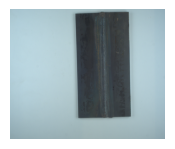

In [145]:
plt.figure(figsize=(2, 2))
plt.imshow(img_cvt)
plt.axis('OFF')
plt.show()

In [146]:
ort_session = onnxruntime.InferenceSession(onnx_model_path)

In [147]:
sam.to(device='cuda')
predictor = SamPredictor(sam)

In [148]:
input_point = np.array([[1500, 375]])
input_label = np.array([0])

In [149]:
onnx_coord = np.concatenate([input_point, np.array([[0.0, 0.0]])], axis=0)[None, :, :]
onnx_label = np.concatenate([input_label, np.array([-1])], axis=0)[None, :].astype(np.float32)

onnx_coord = predictor.transform.apply_coords(onnx_coord, img_cvt.shape[:2]).astype(np.float32)

In [150]:
onnx_mask_input = np.zeros((1, 1, 256, 256), dtype=np.float32)
onnx_has_mask_input = np.zeros(1, dtype=np.float32)

In [151]:
predictor.set_image(img_cvt)
image_embedding = predictor.get_image_embedding().cpu().numpy()

In [152]:
ort_inputs = {
    "image_embeddings": image_embedding,
    "point_coords": onnx_coord,
    "point_labels": onnx_label,
    "mask_input": onnx_mask_input,
    "has_mask_input": onnx_has_mask_input,
    "orig_im_size": np.array(img_cvt.shape[:2], dtype=np.float32)
}

In [153]:
masks, _, low_res_logits = ort_session.run(None, ort_inputs)
masks = masks > predictor.model.mask_threshold

In [154]:
predictor.model.mask_threshold

0.0

In [134]:
def show_mask(mask, ax):
    color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))   

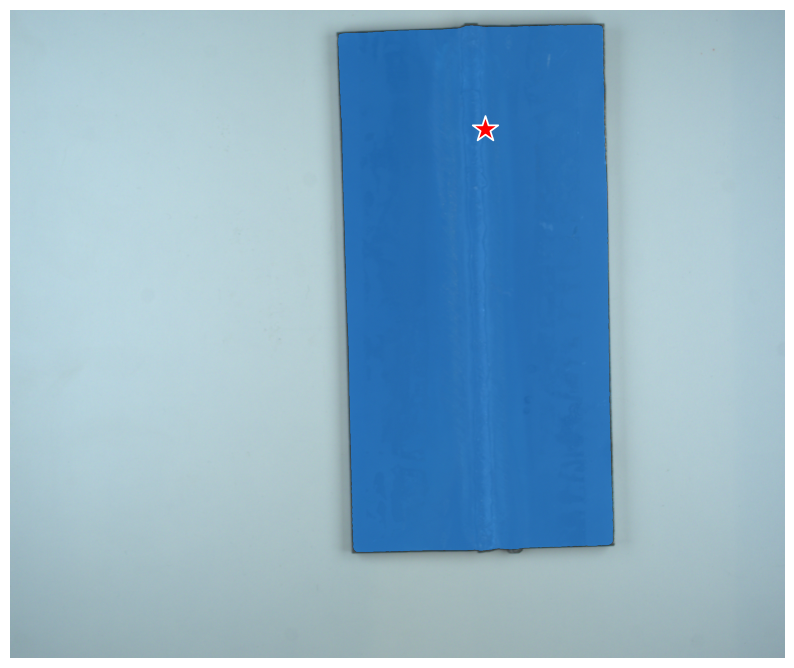

In [155]:
plt.figure(figsize=(10,10))
plt.imshow(img_cvt)
show_mask(masks, plt.gca())
show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.show() 

In [136]:
import plotly.express as px 

px.imshow(img_cvt)


In [156]:
coordinates = np.argwhere(masks == True)

In [167]:
coordinates

array([[   0,    0,   48, 1840],
       [   0,    0,   48, 1841],
       [   0,    0,   48, 1842],
       ...,
       [   0,    0, 1714, 1122],
       [   0,    0, 1714, 1123],
       [   0,    0, 1714, 1124]], dtype=int64)

In [184]:
y2 = max(coordinates.transpose()[3])

In [183]:
y1 = min(coordinates.transpose()[3])

In [178]:
x2 = max(coordinates.transpose()[2])

In [181]:
x1 = min(coordinates.transpose()[2])

In [186]:
cv2.rectangle(img = img_cvt, pt1 = (x1//2, y1), pt2 = (x2//2, y2), color= (0, 255, 9), thickness = 5)

array([[[166, 188, 209],
        [166, 188, 209],
        [166, 192, 208],
        ...,
        [146, 174, 182],
        [146, 171, 183],
        [145, 169, 189]],

       [[166, 188, 209],
        [166, 188, 209],
        [166, 192, 208],
        ...,
        [146, 174, 182],
        [146, 171, 183],
        [145, 169, 189]],

       [[163, 190, 209],
        [163, 190, 209],
        [167, 193, 208],
        ...,
        [149, 174, 182],
        [149, 171, 182],
        [148, 169, 189]],

       ...,

       [[136, 164, 176],
        [136, 164, 176],
        [141, 161, 177],
        ...,
        [140, 164, 169],
        [139, 164, 169],
        [139, 164, 170]],

       [[140, 161, 177],
        [140, 161, 177],
        [136, 161, 177],
        ...,
        [138, 164, 169],
        [144, 162, 170],
        [144, 163, 171]],

       [[141, 161, 174],
        [141, 161, 174],
        [136, 164, 173],
        ...,
        [138, 164, 168],
        [144, 163, 169],
        [144, 163, 171]]

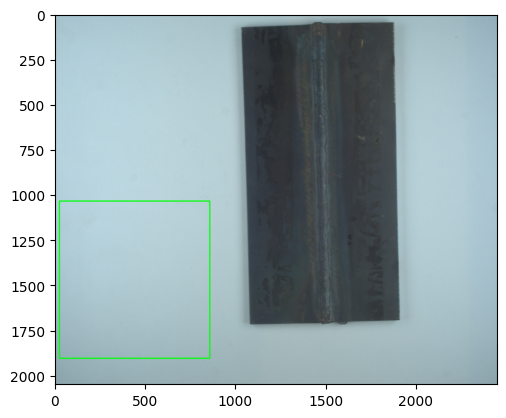

In [187]:
plt.imshow(img_cvt)

In [179]:
x2

1714

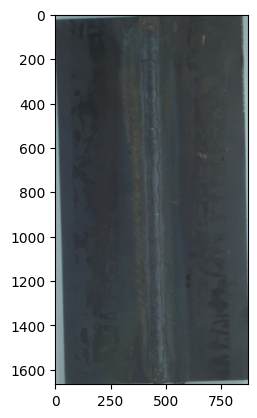

In [185]:
plt.imshow(img_cvt[x1:x2, y1:y2])

In [188]:
import numpy as np

# Your array
arr = np.array([[[[False, False, False, False],
                  [False, False, False, False],
                  [False, False, False, False]],
                 [[False, False, False, False],
                  [False, False, False, False],
                  [False, False, True, False]]]])

# Find the coordinates of the element equal to True
coordinates = np.argwhere(arr == True)

# Print the coordinates
for coord in coordinates:
    print("Coordinates:", coord)


Coordinates: [0 1 2 2]
